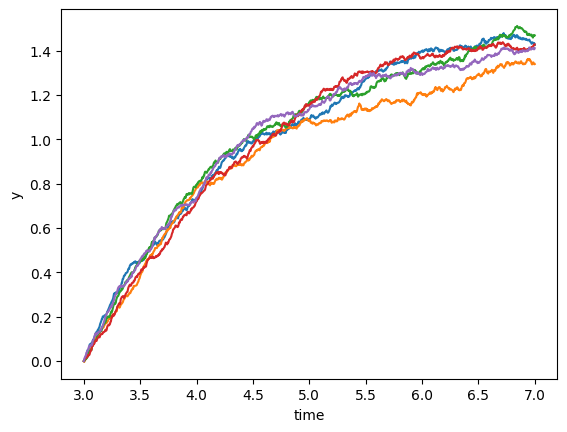

In [ ]:
# # wikipedia code

# # -*- coding: utf-8 -*-
# import numpy as np
# import matplotlib.pyplot as plt


# class Model:
#     """Stochastic model constants."""
#     THETA = 0.7
#     MU = 1.5
#     SIGMA = 0.06


# def mu(y: float, _t: float) -> float:
#     """Implement the Ornstein–Uhlenbeck mu."""
#     return Model.THETA * (Model.MU - y)


# def sigma(_y: float, _t: float) -> float:
#     """Implement the Ornstein–Uhlenbeck sigma."""
#     return Model.SIGMA


# def dW(delta_t: float) -> float:
#     """Sample a random number at each call."""
#     return np.random.normal(loc=0.0, scale=np.sqrt(delta_t))


# def run_simulation():
#     """ Return the result of one full simulation."""
#     T_INIT = 3
#     T_END = 7
#     N = 1000  # Compute at 1000 grid points
#     DT = float(T_END - T_INIT) / N
#     TS = np.arange(T_INIT, T_END + DT, DT)
#     assert TS.size == N + 1

#     Y_INIT = 0

#     ys = np.zeros(TS.size)
#     ys[0] = Y_INIT
#     for i in range(1, TS.size):
#         t = T_INIT + (i - 1) * DT
#         y = ys[i - 1]
#         ys[i] = y + mu(y, t) * DT + sigma(y, t) * dW(DT)

#     return TS, ys


# def plot_simulations(num_sims: int):
#     """ Plot several simulations in one image."""
#     for _ in range(num_sims):
#         plt.plot(*run_simulation())

#     plt.xlabel("time")
#     plt.ylabel("y")
#     plt.show()


# if __name__ == "__main__":
#     NUM_SIMS = 5
#     plot_simulations(NUM_SIMS)

In [ ]:
# Bessel process

# wikipedia code

# -*- coding: utf-8 -*-
import numpy as np
import matplotlib.pyplot as plt

class Model:
    @staticmethod
    def dW(delta_t: float) -> float:
        """Sample a random number at each call."""
        return np.random.normal(loc=0.0, scale=np.sqrt(delta_t))

    @staticmethod
    def dWs(delta_t: float, n: int) -> np.ndarray:
        """Sample n random numbers at each call."""
        return np.random.normal(loc=0.0, scale=np.sqrt(delta_t), size=n)

    def run_euler(self, y0=0):
        """ Return the result of one full simulation."""
        T_INIT = 0
        T_END = 5
        N = 100000  # Compute at 1000 grid points
        DT = float(T_END - T_INIT) / N
        TS = np.arange(T_INIT, T_END + DT, DT)
        assert TS.size == N + 1


        ys = np.zeros(TS.size)
        ys[0] = y0
        for i in range(1, TS.size):
            t = T_INIT + (i - 1) * DT
            y = ys[i - 1]
            ys[i] = y + self.mu(y, t) * DT + self.sigma(y, t) * self.dW(DT)

        return TS, ys

    def run_milstein(self, y0=0):
        """ Return the result of one full simulation."""
        T_INIT = 3
        T_END = 7
        N = 100000
        DT = float(T_END - T_INIT) / N
        TS = np.arange(T_INIT, T_END + DT, DT)
        DWs = self.dWs(DT, N)
        assert TS.size == N + 1
        assert DWs.size == N

        ys = np.zeros(TS.size)
        ys[0] = y0

        for i, DW in zip(range(1, TS.size), DWs):
            _t = T_INIT + (i - 1) * DT
            _y = ys[i - 1]
            mu, sigma = self.mu(_y, _t), self.sigma(_y, _t)
            mu_y, mu_t, mu_yy = self.mu_D(_y,_t)
            sigma_y, sigma_t, sigma_yy = self.sigma_D(_y,_t)

            ys[i] = _y + mu * DT + sigma * DW \
                    + 0.5 * sigma_y * sigma * DW * DT
                    
        return TS, ys

    def plot_simulations(self,  num_sims: int,scheme='euler', **kwargs):
        """ Plot several simulations in one image."""
        simulator = getattr(self, f'run_{scheme}')
        for _ in range(num_sims):
            plt.plot(*simulator(**kwargs))

        plt.xlabel("time")
        plt.ylabel("y")
        plt.title(self.__class__.__name__)

    def mu(self, y: float, _t: float) -> float:
        raise NotImplementedError("mu not implemented")
    def sigma(self, _y: float, _t: float) -> float:
        raise NotImplementedError("sigma not implemented")



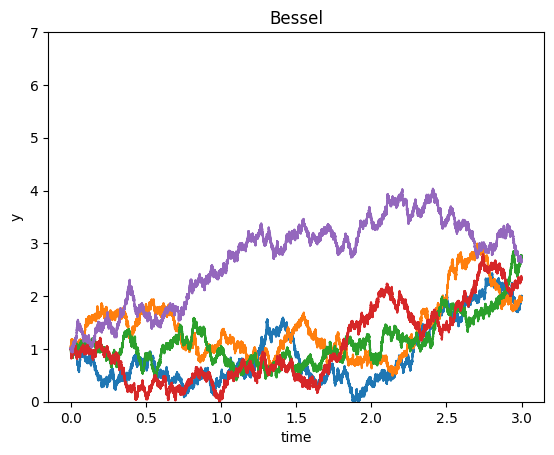

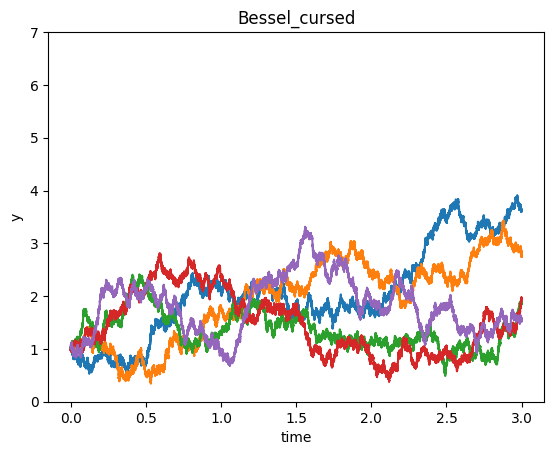

In [14]:

class Bessel(Model):
    n = 2
    a = (n - 1) / 2

    @staticmethod
    def mu(y: float, _t: float) -> float:
        """Implement the Ornstein–Uhlenbeck mu."""
        return Bessel.a / y

    @staticmethod
    def sigma(y: float, _t: float) -> float:
        """Implement the Ornstein–Uhlenbeck sigma."""
        return 1

class Bessel_cursed(Model):
    n = 2
    a = (n - 1) / 2

    @staticmethod
    def mu(y: float, _t: float) -> float:
        """Implement the Ornstein–Uhlenbeck mu."""
        return Bessel.a / y**4

    @staticmethod
    def sigma(y: float, _t: float) -> float:
        """Implement the Ornstein–Uhlenbeck sigma."""
        return 1







if __name__ == "__main__":
    NUM_SIMS = 5
    Bessel().plot_simulations(NUM_SIMS, y0=1)
    Bessel_cursed().plot_simulations(NUM_SIMS, y0=1)

/var/folders/6m/hhdhqqf52hd50wpbypwvsbjc0000gn/T/ipykernel_87705/929452847.py:9: RuntimeWarning: invalid value encountered in double_scalars
  return 2 * (_y * (_y - 1))**0.5
/var/folders/6m/hhdhqqf52hd50wpbypwvsbjc0000gn/T/ipykernel_87705/929452847.py:23: RuntimeWarning: invalid value encountered in double_scalars
  return [(2 * _y - 1) / (_y* (_y - 1))**0.5, 0,
/var/folders/6m/hhdhqqf52hd50wpbypwvsbjc0000gn/T/ipykernel_87705/929452847.py:24: RuntimeWarning: invalid value encountered in double_scalars
  - 1 / (2 * ((_y-1)*(_y))**1.5)]


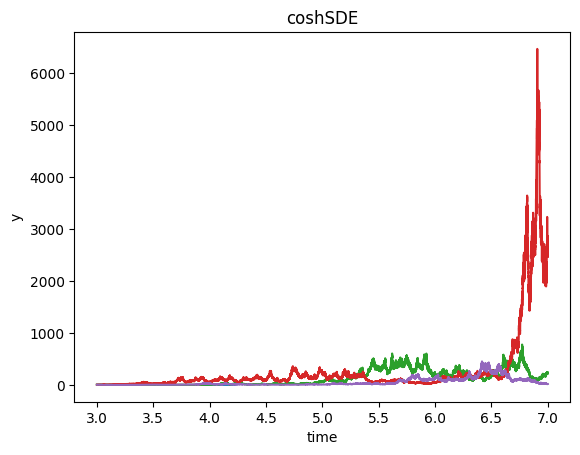

In [35]:
class coshSDE(Model):
    @staticmethod
    def mu(_y: float, _t: float) -> float:
        """Implement the Ornstein–Uhlenbeck mu."""
        return 2 * _y - 1
    @staticmethod
    def sigma(_y: float, _t: float) -> float:
        """Implement the Ornstein–Uhlenbeck sigma."""
        return 2 * (_y * (_y - 1))**0.5
    @staticmethod
    def mu_D(_y: float, _t: float) -> float:
        """
        The derivatives,
        d mu / dy, d mu / dt, d^2 mu / dy^2
        """
        return [2, 0, 0]
    @staticmethod
    def sigma_D(_y: float, _t: float) -> float:
        """
        The derivatives,
        d sigma / dy, d sigma / dt, d^2 sigma / dy^2
        """
        return [(2 * _y - 1) / (_y* (_y - 1))**0.5, 0,
                - 1 / (2 * ((_y-1)*(_y))**1.5)]
    
if __name__ == "__main__":
    NUM_SIMS = 5
    coshSDE().plot_simulations(NUM_SIMS, y0=5, scheme='milstein')


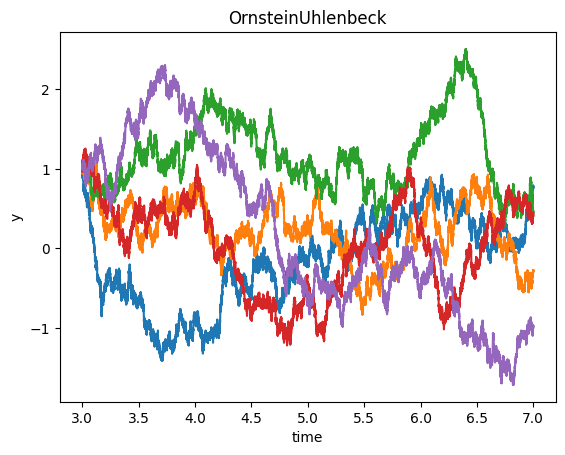

In [44]:
import sympy as sp
from sympy import symbols, Function, Matrix

y, t = symbols('y t')

class AutodiffModel(Model):
    mu_symb = y + 1 + y**2 + t
    sigma_symb = y - 1

    def __init__(self):
        self.mu_lambda = sp.lambdify(
            (y, t), 
            self.mu_symb)
        self.sigma_lambda = sp.lambdify(
            (y, t), 
            self.sigma_symb)
        self.mu_D_lambda = sp.lambdify(
            (y, t), 
            [   
                sp.diff(self.mu_symb, y),
                sp.diff(self.mu_symb, t),
                sp.diff(self.mu_symb, y, 2)
            ])
        self.sigma_D_lambda = sp.lambdify(
            (y, t), 
            [
                sp.diff(self.sigma_symb, y),
                sp.diff(self.sigma_symb, t),
                sp.diff(self.sigma_symb, y, 2)
            ])
    
    def mu(self, _y, _t):
        return self.mu_lambda(_y, _t)

    def sigma(self, _y, _t):
        return self.sigma_lambda(_y, _t)

    def mu_D(self, _y, _t):
        """
        The derivatives,
        d mu / dy, d mu / dt, d^2 mu / dy^2
        """
        return self.mu_D_lambda(_y, _t)
    
    def sigma_D(self, _y, _t):
        """
        The derivatives,
        d sigma / dy, d sigma / dt, d^2 sigma / dy^2
        """
        return self.sigma_D_lambda(_y, _t)
    
class GeomBM(AutodiffModel):
    a = 1
    b = 1
    mu_symb = (a + b / 2) * y
    sigma_symb = b * y

class OrnsteinUhlenbeck(AutodiffModel):
    mu_symb = - y
    sigma_symb = 1

if __name__ == "__main__":
    OrnsteinUhlenbeck().plot_simulations(NUM_SIMS, y0=1, scheme='milstein')


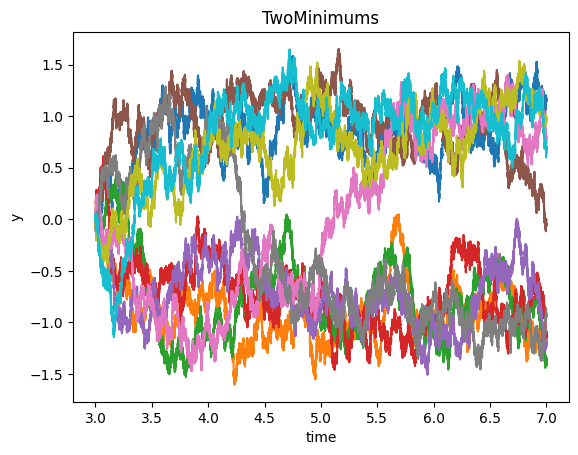

In [48]:
class LangevinMotion(AutodiffModel):
    potential = y**2

    def __init__(self):
        super().__init__()
        self.mu_symb = -self.potential.diff(y)
        self.sigma_symb = 1
        self.mu_lambda = sp.lambdify(
            (y, t), 
            self.mu_symb)
        self.sigma_lambda = sp.lambdify(
            (y, t), 
            self.sigma_symb)
        self.mu_D_lambda = sp.lambdify(
            (y, t), 
            [   
                sp.diff(self.mu_symb, y),
                sp.diff(self.mu_symb, t),
                sp.diff(self.mu_symb, y, 2)
            ])
        self.sigma_D_lambda = sp.lambdify(
            (y, t), 
            [
                sp.diff(self.sigma_symb, y),
                sp.diff(self.sigma_symb, t),
                sp.diff(self.sigma_symb, y, 2)
            ])

class TwoMinimums(LangevinMotion):
    potential = (y**2 - 1)**2

if __name__ == "__main__":
    TwoMinimums().plot_simulations(10, y0=0, scheme='milstein')
        
    
